# Student Math Performance Classification
**Model:** Logistic Regression | **Target:** Grade Group (Fail / Pass / Good / Excellent)

## 1. Import Libraries

In [28]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Load Dataset

In [30]:
path = kagglehub.dataset_download("ishandutta/student-performance-data-set")
df = pd.read_csv(os.path.join(path, "student/student-mat.csv"), sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 3. EDA

In [31]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum(), "total")
print("\nClass distribution of G3:")
print(df["G3"].value_counts().sort_index())

Shape: (395, 33)

Missing values:
 0 total

Class distribution of G3:
G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


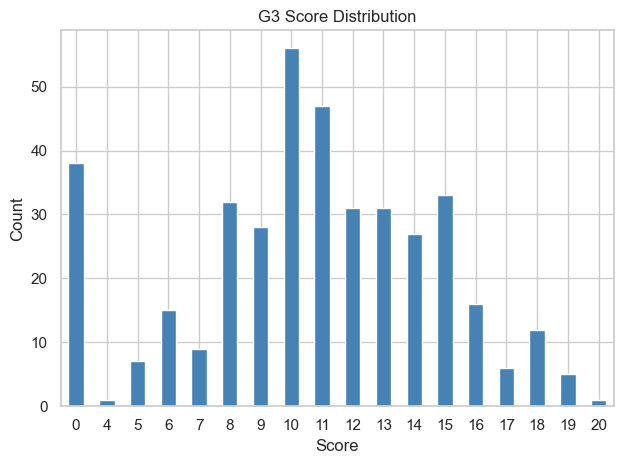

In [32]:
# Grade distribution plot
df["G3"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("G3 Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [33]:
# Create target column from G3
def grade_group(g):
    if g < 10:   return "Fail"
    elif g < 13: return "Pass"
    elif g < 16: return "Good"
    else:        return "Excellent"

df["grade_group"] = df["G3"].apply(grade_group)
print(df["grade_group"].value_counts())

grade_group
Pass         134
Fail         130
Good          91
Excellent     40
Name: count, dtype: int64


In [34]:
# Features and target
X = df.drop(columns=["G3", "grade_group"])
y = df["grade_group"]

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True).astype(float)

# Encode target (fixed order)
order = ["Fail", "Pass", "Good", "Excellent"]
le = LabelEncoder()
le.fit(order)
y = le.transform(y)

print("X shape:", X.shape)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X shape: (395, 41)
Label mapping: {np.str_('Excellent'): np.int64(0), np.str_('Fail'): np.int64(1), np.str_('Good'): np.int64(2), np.str_('Pass'): np.int64(3)}


In [35]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (316, 41)
Test : (79, 41)


In [36]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

## 5. Cross-Validation

In [37]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")

print("CV Scores per Fold:", cv_scores.round(4))
print("Mean Accuracy     :", cv_scores.mean().round(4))
print("Std Deviation     :", cv_scores.std().round(4))

CV Scores per Fold: [0.5938 0.7619 0.6349 0.6984 0.6508]
Mean Accuracy     : 0.668
Std Deviation     : 0.0577


## 6. Train Model

In [38]:
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 7. Evaluation

In [40]:
y_pred = model.predict(X_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test Accuracy: 0.7468

              precision    recall  f1-score   support

   Excellent       0.83      0.62      0.71         8
        Fail       0.96      0.88      0.92        26
        Good       0.55      0.61      0.58        18
        Pass       0.69      0.74      0.71        27

    accuracy                           0.75        79
   macro avg       0.76      0.72      0.73        79
weighted avg       0.76      0.75      0.75        79



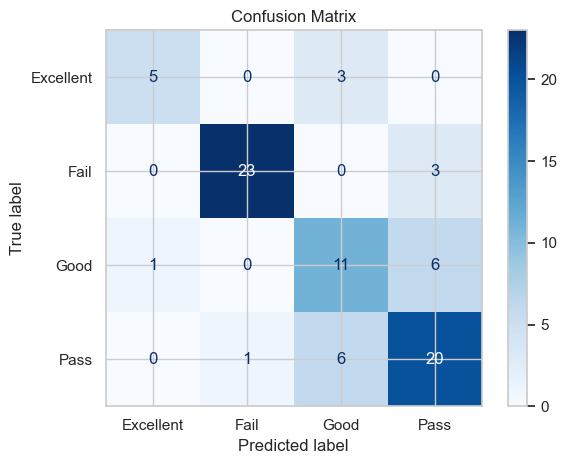

In [41]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [43]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("encoder.pkl", "wb") as f:
    pickle.dump(le, f)

with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Saved.")

Saved.
